# Sold Price vs Listed Price — Correlation & Inference

**Research question:** How correlated are `sold_avg_cents` and `list_low_cents`? Can we reliably infer one from the other?

**Why it matters:** ~34% of rows in `print_price_daily` have no sold price (listing-only). If sold and listed are highly correlated, we can use listed price as a proxy. If not, analyses built on listed price may systematically mis-rank cards.

**Scope:** expansion sets, nonfoil, rare + mythic only — same population as the spike research notebook.

In [2]:
import os
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from scipy import stats

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
PARQUET = DATA_DIR / "sold_vs_list.parquet"
REFRESH = False  # set True to re-query

RARITY_COLORS = {"mythic": "#e07b39", "rare": "#c5a800"}
RARITY_ORDER  = ["mythic", "rare"]

DB_CONFIG = dict(
    host="localhost",
    port=5433,
    dbname="automana",
    user="automana_admin",
    password=os.environ.get("AUTOMANA_DB_PASSWORD", ""),
)

def get_conn():
    return psycopg2.connect(**DB_CONFIG)

def query_to_df(sql):
    with get_conn() as conn:
        cur = conn.cursor()
        cur.execute(sql)
        cols = [d[0] for d in cur.description]
        rows = cur.fetchall()
    return pd.DataFrame(rows, columns=cols)

## Part 0 — Coverage

First: how often does `sold_avg_cents` actually exist for rare and mythic cards? Coverage may differ by rarity, price level, or recency.

In [3]:
SQL_COVERAGE = """
SELECT
    r.rarity_name,
    COUNT(*)                                                         AS total_rows,
    COUNT(*) FILTER (WHERE ppd.sold_avg_cents IS NOT NULL AND ppd.sold_avg_cents > 0) AS has_sold,
    COUNT(*) FILTER (WHERE ppd.list_low_cents  IS NOT NULL AND ppd.list_low_cents  > 0) AS has_list
FROM pricing.print_price_daily ppd
JOIN card_catalog.card_version cv       ON cv.card_version_id = ppd.card_version_id
JOIN card_catalog.rarities_ref r        ON r.rarity_id = cv.rarity_id
JOIN card_catalog.sets s                ON s.set_id = cv.set_id
JOIN card_catalog.set_type_list_ref st  ON st.set_type_id = s.set_type_id
WHERE st.set_type = 'expansion'
  AND ppd.finish_id = 1
  AND r.rarity_name IN ('rare', 'mythic')
GROUP BY r.rarity_name
"""

cov = query_to_df(SQL_COVERAGE)
cov["sold_pct"] = (cov["has_sold"] / cov["total_rows"] * 100).round(1)
cov["list_pct"] = (cov["has_list"] / cov["total_rows"] * 100).round(1)
display(cov[["rarity_name", "total_rows", "has_sold", "sold_pct", "has_list", "list_pct"]])

,rarity_name,total_rows,has_sold,sold_pct,has_list,list_pct
0,mythic,3503393,2261055,64.5,2011685,57.4
1,rare,18131342,12229851,67.5,11182934,61.7


## Part 1 — Load rows where both prices exist

We restrict to rows where **both** `list_low_cents` and `sold_avg_cents` are present and positive — this is the overlap we can actually compare.

In [4]:
SQL = """
SELECT
    r.rarity_name,
    cv.card_version_id,
    ppd.price_date,
    ppd.list_low_cents,
    ppd.list_avg_cents,
    ppd.sold_avg_cents
FROM pricing.print_price_daily ppd
JOIN card_catalog.card_version cv       ON cv.card_version_id = ppd.card_version_id
JOIN card_catalog.rarities_ref r        ON r.rarity_id = cv.rarity_id
JOIN card_catalog.sets s                ON s.set_id = cv.set_id
JOIN card_catalog.set_type_list_ref st  ON st.set_type_id = s.set_type_id
WHERE st.set_type = 'expansion'
  AND ppd.finish_id = 1
  AND ppd.list_low_cents  IS NOT NULL AND ppd.list_low_cents  > 0
  AND ppd.sold_avg_cents  IS NOT NULL AND ppd.sold_avg_cents  > 0
  AND r.rarity_name IN ('rare', 'mythic')
"""

if REFRESH or not PARQUET.exists():
    print("Querying DB…")
    df = query_to_df(SQL)
    df["price_date"] = pd.to_datetime(df["price_date"])
    df.to_parquet(PARQUET, index=False)
    print(f"Saved {len(df):,} rows → {PARQUET}")
else:
    df = pd.read_parquet(PARQUET)
    print(f"Loaded {len(df):,} rows from {PARQUET}")

# work in dollars for readability
df["list_low"]  = df["list_low_cents"]  / 100
df["list_avg"]  = df["list_avg_cents"]  / 100
df["sold_avg"]  = df["sold_avg_cents"]  / 100
df["sold_list_ratio"] = df["sold_avg"] / df["list_low"]

print(f"\nRows by rarity:")
print(df.groupby("rarity_name").size())

Querying DB…
Saved 13,183,638 rows → data/sold_vs_list.parquet

Rows by rarity:
rarity_name
mythic     2008492
rare      11175146
dtype: int64


## Part 2 — Price distribution comparison

How do list and sold prices compare in their distributions? We expect sold to be lower than list (sellers list optimistically), but the question is by how much and how consistently.

In [5]:
# Summary stats: median and percentiles
stats_rows = []
for rarity in RARITY_ORDER:
    sub = df[df["rarity_name"] == rarity]
    for col, label in [("list_low", "list_low"), ("sold_avg", "sold_avg")]:
        q = sub[col].quantile([0.1, 0.25, 0.5, 0.75, 0.9])
        stats_rows.append({
            "rarity": rarity, "price_type": label,
            "p10": q[0.1], "p25": q[0.25], "median": q[0.5],
            "p75": q[0.75], "p90": q[0.9], "mean": sub[col].mean(),
        })

stats_df = pd.DataFrame(stats_rows).set_index(["rarity", "price_type"])
display(stats_df.round(2))

p10   p25  median   p75    p90  mean
rarity price_type                                       
mythic list_low    0.20  0.45    1.50  4.80  12.19  5.14
       sold_avg    0.44  0.92    2.70  6.74  15.32  6.25
rare   list_low    0.05  0.11    0.27  1.48   6.37  6.74
       sold_avg    0.17  0.27    0.65  2.86   9.50  8.39

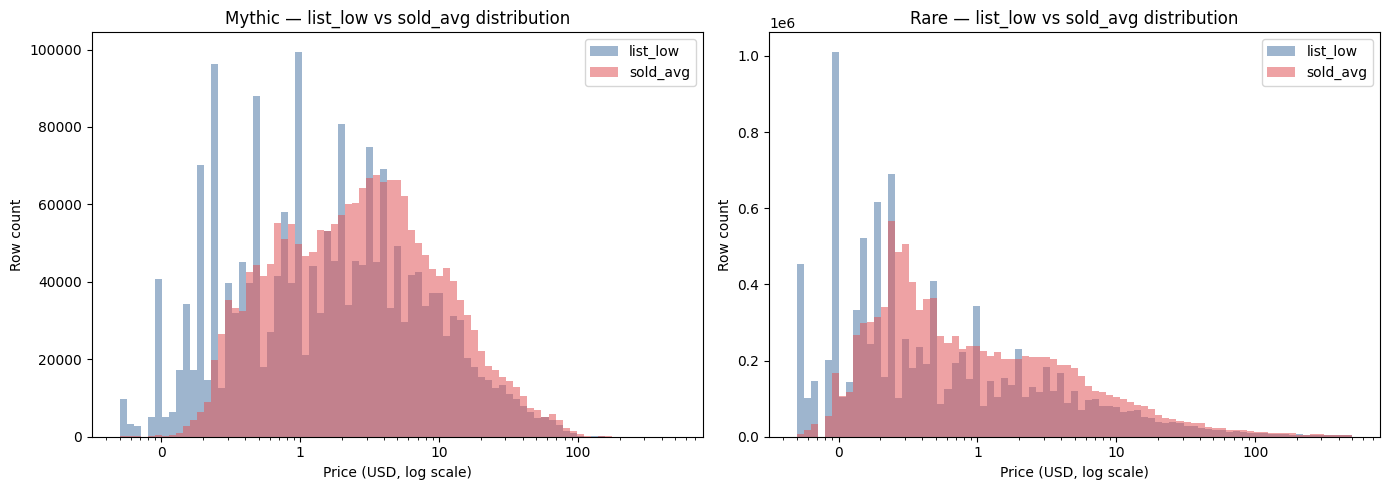

In [6]:
# Log-scale overlapping histograms of list_low vs sold_avg, by rarity
bins = np.logspace(np.log10(0.05), np.log10(500), 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, rarity in zip(axes, RARITY_ORDER):
    sub = df[df["rarity_name"] == rarity]
    ax.hist(sub["list_low"].clip(upper=500), bins=bins, alpha=0.55, color="#4e79a7", label="list_low")
    ax.hist(sub["sold_avg"].clip(upper=500), bins=bins, alpha=0.55, color="#e15759", label="sold_avg")
    ax.set_xscale("log")
    ax.set_xlabel("Price (USD, log scale)")
    ax.set_ylabel("Row count")
    ax.set_title(f"{rarity.capitalize()} — list_low vs sold_avg distribution")
    ax.legend()
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

plt.tight_layout()
plt.savefig(DATA_DIR / "svl_fig1_distributions.png", dpi=150)
plt.show()

## Part 3 — Correlation

We compute:
- **Pearson** on log-transformed prices (appropriate since both are right-skewed)
- **Spearman rank** correlation (robust to outliers, doesn't assume a distribution)

A Spearman ≥ 0.95 means listed price reliably ranks cards by sold price — you'd get the same ordering either way. Below ~0.85 means the relationship is noisy enough to matter.

In [7]:
for rarity in RARITY_ORDER:
    sub = df[df["rarity_name"] == rarity].dropna(subset=["list_low", "sold_avg"])
    log_list = np.log(sub["list_low"])
    log_sold = np.log(sub["sold_avg"])

    pearson_r, pearson_p = stats.pearsonr(log_list, log_sold)
    spearman_r, spearman_p = stats.spearmanr(sub["list_low"], sub["sold_avg"])

    print(f"\n{'='*50}")
    print(f"{rarity.upper()}  (n={len(sub):,})")
    print(f"  Pearson  (log-log): r = {pearson_r:.4f}   p = {pearson_p:.2e}")
    print(f"  Spearman (rank):    r = {spearman_r:.4f}   p = {spearman_p:.2e}")


MYTHIC  (n=2,008,492)
  Pearson  (log-log): r = 0.9789   p = 0.00e+00
  Spearman (rank):    r = 0.9839   p = 0.00e+00

RARE  (n=11,175,146)
  Pearson  (log-log): r = 0.9697   p = 0.00e+00
  Spearman (rank):    r = 0.9659   p = 0.00e+00


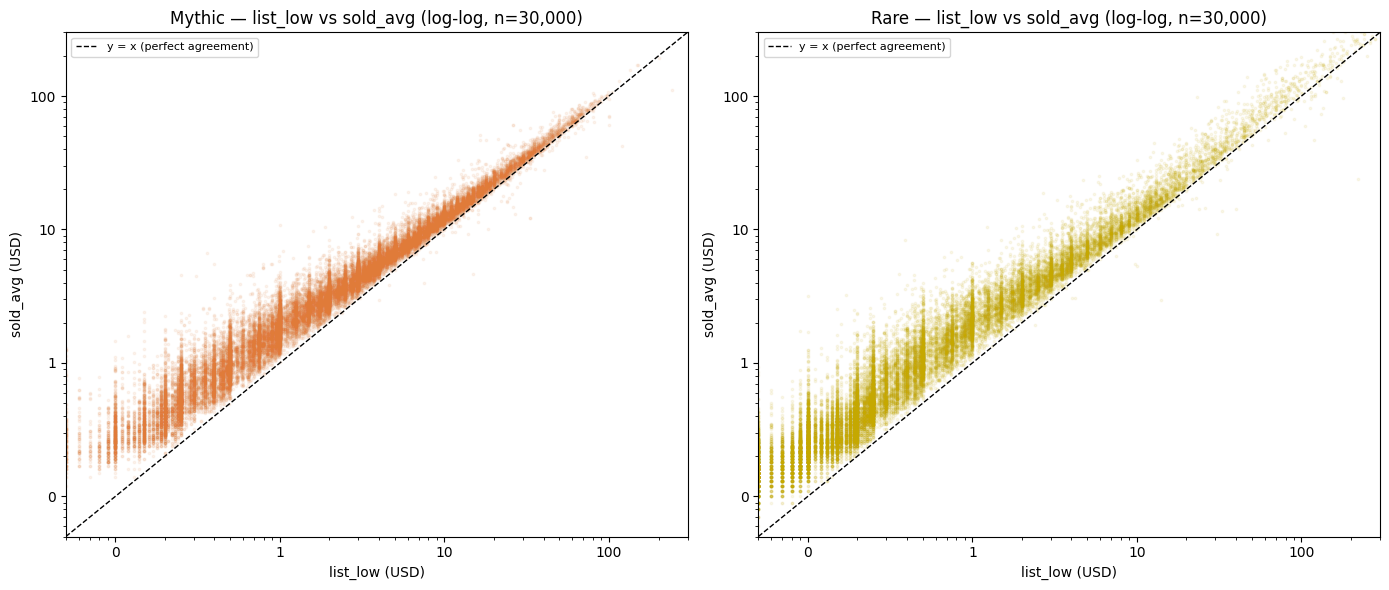

In [8]:
# Log-log scatter: list_low vs sold_avg, sampled for speed
# Perfect inference = points on the diagonal y=x
SAMPLE = 30_000

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, rarity in zip(axes, RARITY_ORDER):
    sub = df[df["rarity_name"] == rarity].sample(min(SAMPLE, len(df[df["rarity_name"] == rarity])), random_state=42)
    ax.scatter(sub["list_low"], sub["sold_avg"], alpha=0.08, s=3, color=RARITY_COLORS[rarity])
    lim = (0.05, 300)
    ax.plot(lim, lim, "k--", linewidth=1, label="y = x (perfect agreement)")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(*lim)
    ax.set_ylim(*lim)
    ax.set_xlabel("list_low (USD)")
    ax.set_ylabel("sold_avg (USD)")
    ax.set_title(f"{rarity.capitalize()} — list_low vs sold_avg (log-log, n={len(sub):,})")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())

plt.tight_layout()
plt.savefig(DATA_DIR / "svl_fig2_scatter.png", dpi=150)
plt.show()

## Part 4 — sold / list ratio

If `sold_avg = k × list_low` for some roughly constant k, we can infer one from the other with a simple multiplier. If k varies systematically with price level, we need a more nuanced model.

We compute `ratio = sold_avg / list_low` and examine:
- Its distribution (is it tight around a constant?)
- Whether it varies by price bucket (cheap vs expensive cards)
- Whether it differs between rare and mythic

sold_avg / list_low ratio distribution:
                  count   mean    std    min    25%  50%    75%   max
rarity_name                                                          
mythic        1999676.0  1.845  0.853  0.104  1.319  1.6  2.079  10.0
rare         10929902.0  2.378  1.312  0.100  1.561  2.0  2.710  10.0


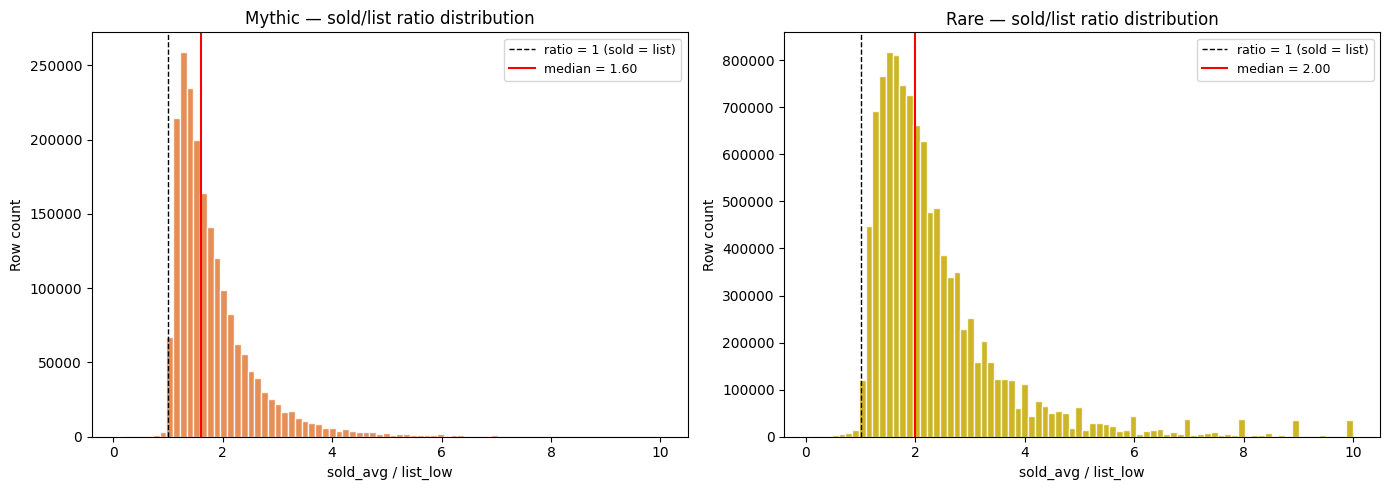

In [9]:
# Cap the ratio at [0.1, 10] to remove extreme outliers (data artifacts)
df_clean = df[(df["sold_list_ratio"] >= 0.1) & (df["sold_list_ratio"] <= 10)].copy()

print("sold_avg / list_low ratio distribution:")
print(df_clean.groupby("rarity_name")["sold_list_ratio"].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, rarity in zip(axes, RARITY_ORDER):
    sub = df_clean[df_clean["rarity_name"] == rarity]["sold_list_ratio"]
    ax.hist(sub, bins=80, color=RARITY_COLORS[rarity], alpha=0.85, edgecolor="white")
    med = sub.median()
    ax.axvline(1.0, color="black", linestyle="--", linewidth=1, label="ratio = 1 (sold = list)")
    ax.axvline(med, color="red", linestyle="-", linewidth=1.5, label=f"median = {med:.2f}")
    ax.set_xlabel("sold_avg / list_low")
    ax.set_ylabel("Row count")
    ax.set_title(f"{rarity.capitalize()} — sold/list ratio distribution")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(DATA_DIR / "svl_fig3_ratio_dist.png", dpi=150)
plt.show()

median_ratio        n
rarity_name price_bucket                       
mythic      <$0.50            2.200000   583517
            $0.50-1           1.896907   282936
            $1-2              1.680000   273717
            $2-5              1.443609   390363
            $5-10             1.292463   222309
            $10-25            1.195455   170706
            $25-50            1.117451    58346
            $50-100           1.079495    17226
            >$100             1.016657      556
rare        <$0.50            2.326531  6663411
            $0.50-1           2.060606  1126137
            $1-2              1.820000   842080
            $2-5              1.534328  1019142
            $5-10             1.372287   509059
            $10-25            1.285068   420569
            $25-50            1.278095   163850
            $50-100           1.288832    82716
            >$100             1.201500    80061

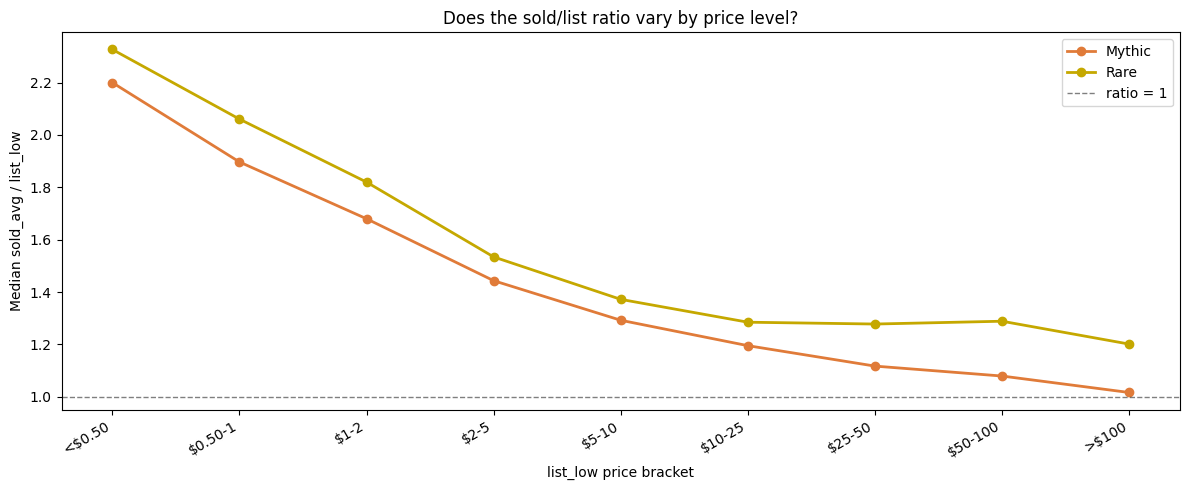

In [10]:
# Does the ratio vary with price level?
# Bin by list_low price bracket and compute median ratio per bin
PRICE_BINS   = [0, 0.5, 1, 2, 5, 10, 25, 50, 100, 500]
PRICE_LABELS = ["<$0.50", "$0.50-1", "$1-2", "$2-5", "$5-10", "$10-25", "$25-50", "$50-100", ">$100"]

df_clean["price_bucket"] = pd.cut(df_clean["list_low"], bins=PRICE_BINS, labels=PRICE_LABELS)

ratio_by_bucket = (
    df_clean.groupby(["rarity_name", "price_bucket"], observed=True)["sold_list_ratio"]
    .agg(["median", "count"])
    .rename(columns={"median": "median_ratio", "count": "n"})
)
display(ratio_by_bucket)

fig, ax = plt.subplots(figsize=(12, 5))
for rarity in RARITY_ORDER:
    sub = ratio_by_bucket.loc[rarity].reset_index()
    sub = sub[sub["n"] >= 50]  # skip bins with too few points
    ax.plot(sub["price_bucket"].astype(str), sub["median_ratio"],
            marker="o", linewidth=2, color=RARITY_COLORS[rarity], label=rarity.capitalize())

ax.axhline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.5, label="ratio = 1")
ax.set_xlabel("list_low price bracket")
ax.set_ylabel("Median sold_avg / list_low")
ax.set_title("Does the sold/list ratio vary by price level?")
ax.legend()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(DATA_DIR / "svl_fig4_ratio_by_price.png", dpi=150)
plt.show()

## Part 5 — Can we infer sold from listed? (log-log regression)

We fit `log(sold_avg) = a + b × log(list_low)` per rarity.

- If **b ≈ 1** and **R² ≈ 1**: sold ≈ constant × list — a simple multiplier suffices.
- If **b < 1**: sold prices are compressed relative to list at the high end — cheap and expensive cards have a smaller ratio gap than list prices suggest.
- **R²** tells you how much variance in sold price is explained by listed price alone.


MYTHIC
  log(sold) = 0.612 + 0.837 × log(list_low)
  R² = 0.9662  → list_low explains 96.6% of variance in sold_avg
  Implied multiplier at list=$1:  sold ≈ $1.84
  Implied multiplier at list=$10: sold ≈ $12.66

RARE
  log(sold) = 0.654 + 0.861 × log(list_low)
  R² = 0.9567  → list_low explains 95.7% of variance in sold_avg
  Implied multiplier at list=$1:  sold ≈ $1.92
  Implied multiplier at list=$10: sold ≈ $13.96


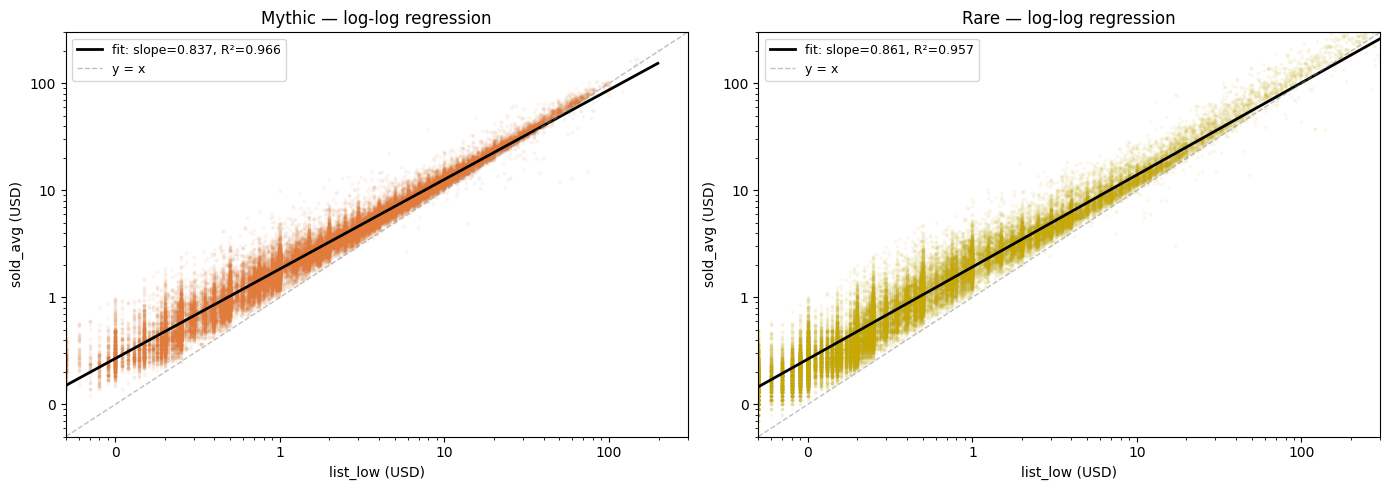

In [11]:
from scipy.stats import linregress

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, rarity in zip(axes, RARITY_ORDER):
    sub = df_clean[df_clean["rarity_name"] == rarity].sample(min(50_000, len(df_clean[df_clean["rarity_name"] == rarity])), random_state=42)
    log_x = np.log(sub["list_low"])
    log_y = np.log(sub["sold_avg"])

    slope, intercept, r, p, se = linregress(log_x, log_y)
    r2 = r ** 2

    x_range = np.linspace(log_x.min(), log_x.max(), 200)
    y_fit   = intercept + slope * x_range

    ax.scatter(np.exp(log_x), np.exp(log_y), alpha=0.05, s=3, color=RARITY_COLORS[rarity])
    ax.plot(np.exp(x_range), np.exp(y_fit), color="black", linewidth=2,
            label=f"fit: slope={slope:.3f}, R²={r2:.3f}")
    ax.plot([0.05, 300], [0.05, 300], "--", color="grey", linewidth=1, alpha=0.5, label="y = x")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(0.05, 300)
    ax.set_ylim(0.05, 300)
    ax.set_xlabel("list_low (USD)")
    ax.set_ylabel("sold_avg (USD)")
    ax.set_title(f"{rarity.capitalize()} — log-log regression")
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())

    print(f"\n{rarity.upper()}")
    print(f"  log(sold) = {intercept:.3f} + {slope:.3f} × log(list_low)")
    print(f"  R² = {r2:.4f}  → list_low explains {r2*100:.1f}% of variance in sold_avg")
    print(f"  Implied multiplier at list=$1:  sold ≈ ${np.exp(intercept):.2f}")
    print(f"  Implied multiplier at list=$10: sold ≈ ${np.exp(intercept + slope*np.log(10)):.2f}")

plt.tight_layout()
plt.savefig(DATA_DIR / "svl_fig5_regression.png", dpi=150)
plt.show()

## Part 6 — Conclusion & Recommendation

Summary of findings and whether spike research should switch to sold price, use listed as a proxy, or combine both.

In [12]:
print("SUMMARY")
print("=" * 55)
for rarity in RARITY_ORDER:
    sub = df_clean[df_clean["rarity_name"] == rarity]
    ratio = sub["sold_list_ratio"]
    log_x = np.log(sub["list_low"])
    log_y = np.log(sub["sold_avg"])
    slope, intercept, r, _, _ = linregress(log_x, log_y)
    spearman_r, _ = stats.spearmanr(sub["list_low"], sub["sold_avg"])
    print(f"\n{rarity.upper()} (n={len(sub):,})")
    print(f"  Spearman rank corr:   {spearman_r:.3f}")
    print(f"  Log-log R²:           {r**2:.3f}")
    print(f"  Median sold/list:     {ratio.median():.3f}")
    print(f"  IQR sold/list:        [{ratio.quantile(0.25):.2f}, {ratio.quantile(0.75):.2f}]")
    print(f"  Regression slope:     {slope:.3f}  (1.0 = pure multiplier)")

SUMMARY

MYTHIC (n=1,999,676)
  Spearman rank corr:   0.985
  Log-log R²:           0.966
  Median sold/list:     1.600
  IQR sold/list:        [1.32, 2.08]
  Regression slope:     0.836  (1.0 = pure multiplier)

RARE (n=10,929,902)
  Spearman rank corr:   0.969
  Log-log R²:           0.957
  Median sold/list:     2.000
  IQR sold/list:        [1.56, 2.71]
  Regression slope:     0.860  (1.0 = pure multiplier)
